<h1 style="text-align: center;">Deep Learning Project</h1>

** **

## <p style="text-align: center;"><i>03 - Modeling </i></p>

** **
<p style="text-align: center;">
David Cascão - 20240851 <br>
Jan-Louis Schneider - 20240506 <br>
Emir Kamiloglu - 20240945 <br>
Marta Boavida - 20240519 <br>
Sofia Gomes - 20240848
</p>


## <span style="color:#FF007F"> Notebook </span> 

In this notebook, we prepare out data for the models, create and train the models and quickly visualize the indivudal results and metrics of the models. In total we create 5 models, one baseline model, two more advanced versions of this baseline model with special tuning, and two pretrained models.


## <span style="color:#FF007F">Table of Contents</span>

<a class="anchor" id="top"></a>

1. [Mounting Google Drive & Getting the Files](one-bullet)

2. [GPU Check for Torch](#two-bullet) <br>

3. [Import Libraries](#tree-bullet) <br>

4. [Load Preprocessed Metadata](#four-bullet) <br>

5. [Build Final Training Set from aug_paths and original_path](#five-bullet) <br>

6. [Preparing Custom Datasets and DataLoaders for Image Classification](#six-bullet) <br>

7. [Model Training](#seven-bullet) <br>

    7.1 [Baseline Model using CNN](#seven-one-bullet) <br>

    7.2 [Improved Model Based on Baseline CNN Model](#seven-two-bullet) <br>

    7.3 [More complex CNN Model](#seven-tree-bullet) <br>

    7.4 [Pretrained Model ResNet50](#seven-four-bullet) <br>

    7.5 [Pretrained Model VGG16](#seven-five-bullet) <br>

<a class="anchor" id="one-bullet"></a>

## <span style="color:#FF007F"> 1. Mounting Google Drive & Getting the Files </span>  

<a href="#top">Top &#129033;</a>

We imported the data in a zip files from Google Drive first and unzipped it on Google Colab, the images were being pulled from Drive while training the model before and this was slowing down the training progress even though we are working with highly capable GPU's available on Google Colab platform.

Below we created functions to:
*   Mount the Google Drive Folder
*   Copying the ZIP file to Colab local disk from Drive
*   Unzipping the zip file pulled from Drive in Colab local for faster access.
*   Remove the ZIP file from local Colab storage


In [1]:
import shutil
import os
from google.colab import drive

In [2]:
# Mount Google Drive
def mount_drive():
    drive.mount('/content/drive')

# Copy ZIP file from Drive to Colab local disk
def copy_zip_to_local(zip_path):
    !cp {zip_path} /content/

def unzip_dataset(zip_filename, extract_to='/content/deep_learning_project'):
    # Remove existing dataset folder to avoid duplication
    if not os.path.exists(extract_to):
        os.makedirs(extract_to)

    temp_folder = '/content/temp_unzip_folder'

    if os.path.exists(temp_folder):
        shutil.rmtree(temp_folder)

    os.makedirs(temp_folder)
    print(f"Created temporary folder: {temp_folder}")

    !unzip -q /content/{zip_filename} -d {temp_folder}

    # Move everything inside temp_folder's first subfolder to extract_to
    inner_folder = os.path.join(temp_folder, os.listdir(temp_folder)[0])

    for item in os.listdir(inner_folder):
        shutil.move(os.path.join(inner_folder, item), extract_to)

    shutil.rmtree(temp_folder)
    print(f"Moved files and cleaned temporary folder: {temp_folder}")

    return extract_to

# Remove the ZIP file from local Colab storage
def remove_local_zip(zip_filename):
    zip_path = f"/content/{zip_filename}"
    if os.path.exists(zip_path):
        os.remove(zip_path)
        print(f"Removed local zip file: {zip_path}")
    else:
        print(f"Zip file not found: {zip_path}")

We executed these functions in the code below, imported the zip and unzipped it successfully to our local disk on Colab environment.

In [3]:
mount_drive()
copy_zip_to_local('/content/drive/MyDrive/deep_learning_project/deep_learning_project_data.zip')
data_root_dir = unzip_dataset('deep_learning_project_data.zip')
remove_local_zip('deep_learning_project_data.zip')

Mounted at /content/drive
Created temporary folder: /content/temp_unzip_folder
Moved files and cleaned temporary folder: /content/temp_unzip_folder
Removed local zip file: /content/deep_learning_project_data.zip


In [4]:
data_root_dir

'/content/deep_learning_project'

<a class="anchor" id="two-bullet"></a>

## <span style="color:#FF007F"> 2. GPU Check for Torch </span>  

<a href="#top">Top &#129033;</a>

On the code below, we imported torch and checked if we have CUDA(GPU) available for us to use to confirm.


**Note:** In our classes we used Tensorflow/Keras for modelling purposes, we also tried using tensorflow.keras both locally and on Colab. However there was an issue we couldn't fix after so much effort. For some reason using keras, models always predicted only 1 class. So the we tried PyTorch and this issue did not appear, so we kept Torch and rebuilt our notebooks with it.

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


<a class="anchor" id="three-bullet"></a>

## <span style="color:#FF007F">3. Import Libraries </span>  

<a href="#top">Top &#129033;</a>


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import ast

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.functional import softmax
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchvision import transforms
from torchvision import models ## To import pre-trained models such as ResNet50 and VGG16

from collections import Counter
from collections import defaultdict
from tqdm import tqdm

from PIL import Image
Image.MAX_IMAGE_PIXELS = Image.MAX_IMAGE_PIXELS * 2

<a class="anchor" id="four-bullet"></a>

## <span style="color:#FF007F">4. Load Preprocessed Metadata</span>  

<a href="#top">Top &#129033;</a>

In [8]:
import os
os.chdir('/content/deep_learning_project')
print(os.getcwd())

/content/deep_learning_project


1. Normalize Windows-style paths to POSIX-style for Colab

Because the Windows style path use "\" in paths and has leading "\" characters in the paths, we needed to manipulate them to be in POSIX style for them to be working in Google Colab.

On the code below you can see 2 functions we created to make

In [9]:
def normalize_path(path):
    if pd.notnull(path):
        path = path.replace('\\', '/')  # replace double backslashes
        path = path.replace('..\\', '')  # remove parent dir markers
        path = path.replace('..', '') # remove remaining ".."
        path = path.replace('\\', '/')  # replace remaining single backslashes again for safety
        path = path.replace(' ', '_')  # replace spaces with underscores
        path = path.lstrip('/')  # remove leading slash
    return path

def normalize_paths_column(col):
    def safe_eval_list(x):
        if isinstance(x, str):
            try:
                x = ast.literal_eval(x)
            except:
                return []
        if isinstance(x, list):
            return [normalize_path(p) for p in x if isinstance(p, str)]
        return []
    return col.apply(safe_eval_list)


On the code below we set our directories for related folders and then import metadata from our preprocessing notebooks.

In [10]:
metadata_dir = 'preprocessed'
image_dir_train = 'data_preprocessed/train'
image_dir_val = 'data'

train_df = pd.read_csv(os.path.join(metadata_dir, 'train_df_preproc_clip_aug.csv'))
val_df = pd.read_csv(os.path.join(metadata_dir, 'val_df_preproc_clip.csv'))
test_df = pd.read_csv(os.path.join(metadata_dir, 'test_df_preproc_clip.csv'))

You can see on the head() table above that we have the paths in Windows format. 

In [11]:
train_df.head(5)

,original_class,original_path,clip_class,clip_top3_match_probs,clip_status,aug_transforms,aug_paths
0,arthropoda_papilionidae,..\data\arthropoda_papilionidae\29510023_13054...,arthropoda_papilionidae,"{'insect': 0.3370007574558258, 'a healthy anim...",0,"[{'__class_fullname__': 'ReplayCompose', 'para...",['..\\data_preprocessed\\train\\arthropoda_pap...
1,chordata_rhinodermatidae,..\data\chordata_rhinodermatidae\28493262_9950...,chordata_rhinodermatidae,"{'insect': 0.29881036281585693, 'scientific il...",0,"[{'__class_fullname__': 'ReplayCompose', 'para...",['..\\data_preprocessed\\train\\chordata_rhino...
2,chordata_carcharhinidae,..\data\chordata_carcharhinidae\29347816_46559...,chordata_carcharhinidae,"{'animal on human hands': 0.3224937319755554, ...",0,"[{'__class_fullname__': 'ReplayCompose', 'para...",['..\\data_preprocessed\\train\\chordata_carch...
3,arthropoda_tettigoniidae,..\data\arthropoda_tettigoniidae\29822048_8587...,arthropoda_tettigoniidae,"{'insect': 0.7299895286560059, 'a detailed clo...",0,"[{'__class_fullname__': 'ReplayCompose', 'para...",['..\\data_preprocessed\\train\\arthropoda_tet...
4,arthropoda_apidae,..\data\arthropoda_apidae\21834170_1065290_eol...,arthropoda_apidae,"{'insect': 0.3581487238407135, 'a clear photo ...",0,"[{'__class_fullname__': 'ReplayCompose', 'para...",['..\\data_preprocessed\\train\\arthropoda_api...


Below we use our path normalization functions to get them in POSIX format which is compatible with Colab.

In [12]:
# Apply normalization to all relevant DataFrame columns
train_df['aug_paths'] = normalize_paths_column(train_df['aug_paths'])
train_df['original_path'] = train_df['original_path'].apply(normalize_path)

val_df['aug_paths'] = normalize_paths_column(val_df['aug_paths'])
val_df['original_path'] = val_df['original_path'].apply(normalize_path)

test_df['aug_paths'] = normalize_paths_column(test_df['aug_paths'])
test_df['original_path'] = test_df['original_path'].apply(normalize_path)

In [13]:
train_df.head()

,original_class,original_path,clip_class,clip_top3_match_probs,clip_status,aug_transforms,aug_paths
0,arthropoda_papilionidae,data/arthropoda_papilionidae/29510023_130548_e...,arthropoda_papilionidae,"{'insect': 0.3370007574558258, 'a healthy anim...",0,"[{'__class_fullname__': 'ReplayCompose', 'para...",[data_preprocessed/train/arthropoda_papilionid...
1,chordata_rhinodermatidae,data/chordata_rhinodermatidae/28493262_995017_...,chordata_rhinodermatidae,"{'insect': 0.29881036281585693, 'scientific il...",0,"[{'__class_fullname__': 'ReplayCompose', 'para...",[data_preprocessed/train/chordata_rhinodermati...
2,chordata_carcharhinidae,data/chordata_carcharhinidae/29347816_46559811...,chordata_carcharhinidae,"{'animal on human hands': 0.3224937319755554, ...",0,"[{'__class_fullname__': 'ReplayCompose', 'para...",[data_preprocessed/train/chordata_carcharhinid...
3,arthropoda_tettigoniidae,data/arthropoda_tettigoniidae/29822048_858738_...,arthropoda_tettigoniidae,"{'insect': 0.7299895286560059, 'a detailed clo...",0,"[{'__class_fullname__': 'ReplayCompose', 'para...",[data_preprocessed/train/arthropoda_tettigonii...
4,arthropoda_apidae,data/arthropoda_apidae/21834170_1065290_eol-fu...,arthropoda_apidae,"{'insect': 0.3581487238407135, 'a clear photo ...",0,"[{'__class_fullname__': 'ReplayCompose', 'para...",[data_preprocessed/train/arthropoda_apidae/aug...


As you can see in the head() output, our paths are now in correct format.

In [14]:
train_df["aug_paths"][1]

['data_preprocessed/train/chordata_rhinodermatidae/aug_000_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_001_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_002_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_003_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_004_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_005_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_006_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_007_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_008_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_009_28493262_995017_eol-full-size-copy.jpg']

In [15]:
print(type(train_df["aug_paths"][1]))

<class 'list'>


On our preprocessing step, we used CLIP to mark the images without animals, we are removing those paths from our dataset to not confuse our model with unrelated images.

In [16]:
# Remove non-animal samples
target_class = 'non_animal'
train_df = train_df[train_df['clip_class'] != target_class]
val_df = val_df[val_df['clip_class'] != target_class]
test_df = test_df[test_df['clip_class'] != target_class]

In [17]:
train_df["aug_paths"][1]

['data_preprocessed/train/chordata_rhinodermatidae/aug_000_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_001_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_002_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_003_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_004_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_005_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_006_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_007_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_008_28493262_995017_eol-full-size-copy.jpg',
 'data_preprocessed/train/chordata_rhinodermatidae/aug_009_28493262_995017_eol-full-size-copy.jpg']

In [18]:
print(len(train_df))

8380



<a class="anchor" id="six-bullet"></a>

## <span style="color:#FF007F">5. Build Final Training Set from aug_paths and original_path (Not including bg_path)</span>  

<a href="#top">Top &#129033;</a>

This code builds a DataFrame combining file paths and classes from both augmented images and valid original images

In [19]:
final_train_df = pd.concat([
    pd.DataFrame([
        {'filepath': p, 'original_class': r['original_class']}
        for _, r in train_df.iterrows()
        if isinstance(r['aug_paths'], list) and len(r['aug_paths']) > 0
        for p in r['aug_paths']
    ]),
    train_df[train_df['original_path'].notna()].assign(
        filepath=lambda x: x['original_path']
    )[['filepath', 'original_class']]
], ignore_index=True)

And then prints the total number of rows in the final_train_df

In [20]:
print(len(final_train_df))

45298


**1. Label encoding for model input**

In order to fit the data, we use LabelEncoder on the training data, validation and test to avoid data leakage.

In [21]:
le_family = LabelEncoder()
final_train_df['original_encoded'] = le_family.fit_transform(final_train_df['original_class'])

#only transform no fit_transform for validation and test, to avoid data leakage
final_val_df = val_df[val_df['original_path'].notna()].assign(filepath=lambda x: x['original_path'])
final_val_df['original_encoded'] = le_family.transform(final_val_df['original_class'])

final_test_df = test_df[test_df['original_path'].notna()].assign(filepath=lambda x: x['original_path'])
final_test_df['original_encoded'] = le_family.transform(final_test_df['original_class'])

Checkup: Checking whether if the encoding is successful and if there are missing variables.

In [22]:
print("Final training dataset shape:", final_train_df.shape)
print(final_train_df.head())

print("Validation dataset shape:", final_val_df.shape)
print("Test dataset shape:", final_test_df.shape)

print(final_train_df['original_class'].nunique())
print(final_val_df['original_class'].nunique())
print(final_test_df['original_class'].nunique())

Final training dataset shape: (45298, 3)
                                            filepath           original_class  \
0  data_preprocessed/train/arthropoda_papilionida...  arthropoda_papilionidae   
1  data_preprocessed/train/arthropoda_papilionida...  arthropoda_papilionidae   
2  data_preprocessed/train/arthropoda_papilionida...  arthropoda_papilionidae   
3  data_preprocessed/train/arthropoda_papilionida...  arthropoda_papilionidae   
4  data_preprocessed/train/arthropoda_papilionida...  arthropoda_papilionidae   

   original_encoded  
0                10  
1                10  
2                10  
3                10  
4                10  
Validation dataset shape: (1686, 9)
Test dataset shape: (1131, 9)
202
202
202


Below we check specific paths from validation and test dataframes and whether if the image exit on that path.

In [23]:
# Check if paths work
# Checking train dataframe
print(final_train_df['filepath'].iloc[1])
print(os.path.exists(final_train_df['filepath'].iloc[1]))

# Checking validation dataframe
print(final_val_df['filepath'].iloc[100])
print(os.path.exists(final_val_df['filepath'].iloc[100]))

# Checking test dataframe
print(final_test_df['filepath'].iloc[100])
print(os.path.exists(final_test_df['filepath'].iloc[100]))

data_preprocessed/train/arthropoda_papilionidae/aug_001_29510023_130548_eol-full-size-copy.jpg
True
data/echinodermata_stichopodidae/29384427_2984557_eol-full-size-copy.jpg
True
data/chordata_thraupidae/20769934_1050315_eol-full-size-copy.jpg
True


Below we import 5 images per training, validation and test to confirm the images are being pulled successfully.

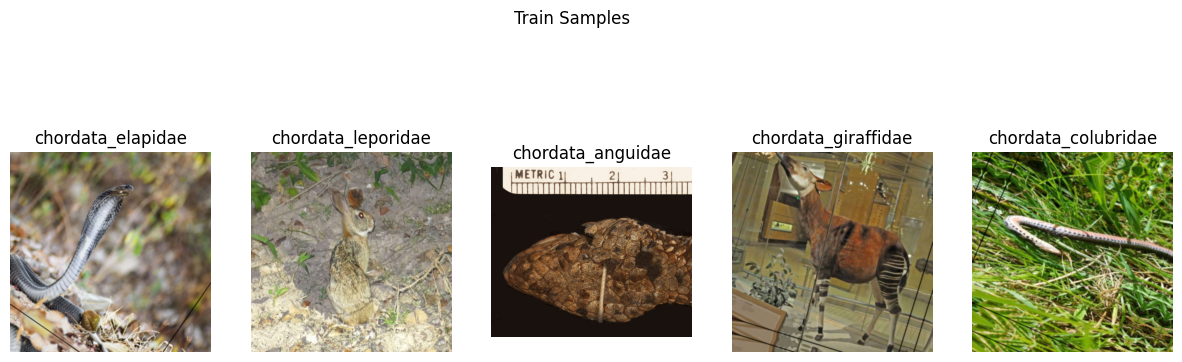

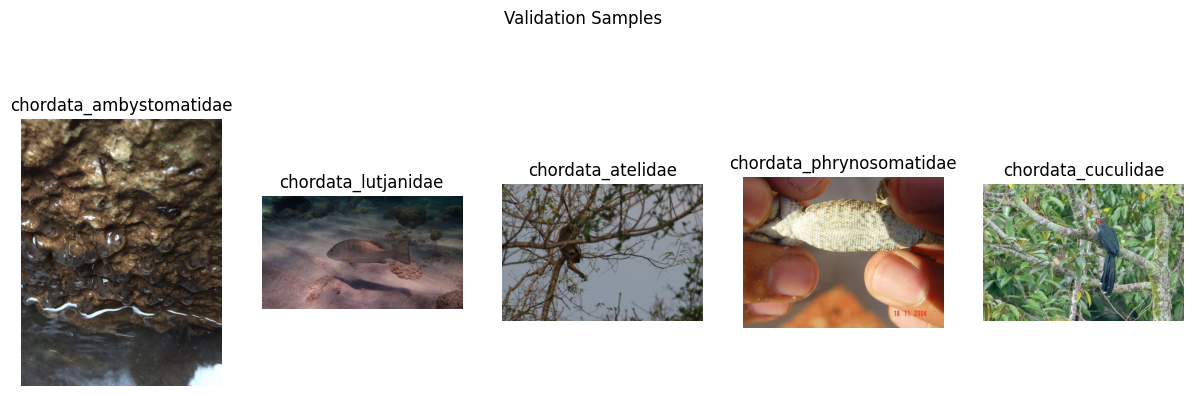

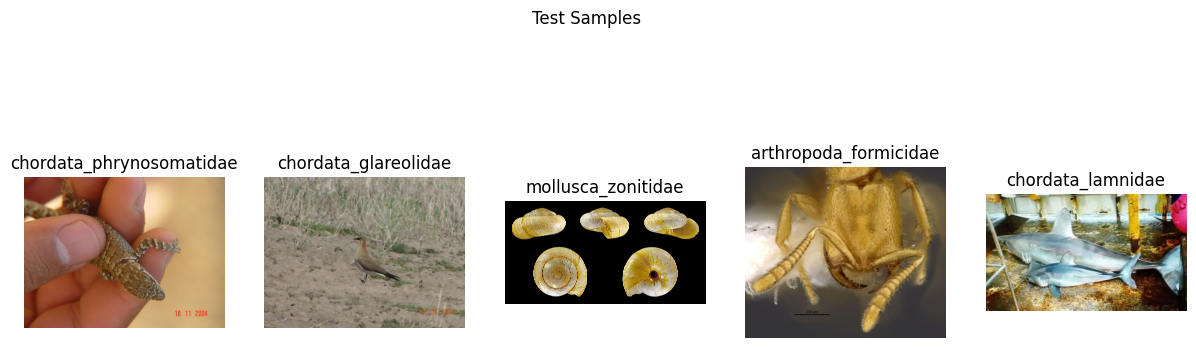

In [24]:
# Randomly display 5 images from each dataset
def plot_sample_images(df, title, n=5):
    sample_df = df.sample(n=n)
    plt.figure(figsize=(15, 5))
    for i, path in enumerate(sample_df['filepath']):
        plt.subplot(1, n, i+1)
        img = Image.open(path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(sample_df.iloc[i]['original_class'])
    plt.suptitle(title)
    plt.show()

plot_sample_images(final_train_df, "Train Samples")
plot_sample_images(final_val_df, "Validation Samples")
plot_sample_images(final_test_df, "Test Samples")

**2. Quick exploration before encoding**

On this part we check head and tail sections of our dataframes original_class counts. As well as unique family count and sample sizes.

In [ ]:
# Unique familty count
print("\nNumber of unique families:", final_train_df['original_class'].nunique())
print("Total training samples:", len(final_train_df))

print("\nNumber of unique families:", final_val_df['original_class'].nunique())
print("Total validation samples:", len(final_val_df))

print("\nNumber of unique families:", final_test_df['original_class'].nunique())
print("Total test samples:", len(final_test_df))


Number of unique families: 202
Total training samples: 45298

Number of unique families: 202
Total validation samples: 1686

Number of unique families: 202
Total test samples: 1131


Here we can see the top 5 with most images

In [26]:
# to see top 5 classes with most images
print("\n training data overview (head)")
print(final_train_df['original_class'].value_counts().head(5))

print("\n Validation data overview (head)")
print(final_val_df['original_class'].value_counts().head(5))

print("\n Test data Overview (head)")
print(final_test_df['original_class'].value_counts().head(5))


 training data overview (head)
original_class
chordata_plethodontidae    417
arthropoda_formicidae      395
chordata_salamandridae     391
chordata_carcharhinidae    372
chordata_dasyatidae        315
Name: count, dtype: int64

 Validation data overview (head)
original_class
chordata_dactyloidae        44
chordata_cercopithecidae    44
arthropoda_formicidae       42
chordata_salamandridae      41
chordata_plethodontidae     41
Name: count, dtype: int64

 Test data Overview (head)
original_class
chordata_cercopithecidae    29
chordata_dactyloidae        29
arthropoda_formicidae       29
chordata_salamandridae      27
chordata_plethodontidae     27
Name: count, dtype: int64


And here the 5 classes with least images

In [27]:
#to see 5 classes with least images
print("\n training data overview (tail)")
print(final_train_df['original_class'].value_counts().tail(5))

print("\n Validation data overview (tail)")
print(final_val_df['original_class'].value_counts().tail(5))

print("\n Test data Overview (tail)")
print(final_test_df['original_class'].value_counts().tail(5))


 training data overview (tail)
original_class
chordata_strigopidae       196
chordata_columbidae        196
arthropoda_palinuridae     195
chordata_phyllostomidae    195
chordata_pristidae         193
Name: count, dtype: int64

 Validation data overview (tail)
original_class
chordata_gavialidae           3
chordata_pontoporiidae        3
chordata_alligatoridae        2
chordata_brachypteraciidae    1
mollusca_conidae              1
Name: count, dtype: int64

 Test data Overview (tail)
original_class
chordata_cetorhinidae         2
chordata_rhinodermatidae      2
chordata_paradisaeidae        2
chordata_brachypteraciidae    1
chordata_pristidae            1
Name: count, dtype: int64


<a class="anchor" id="seven-bullet"></a>

## <span style="color:#FF007F"> 6. Preparing Custom Datasets and DataLoaders for Image Classification</span>  

<a href="#top">Top &#129033;</a>

In this section, we prepare our training, validation, and test datasets and also prepared the necessary data loaders to be used in a model.
1. We define custom dataset classes:
    *   SimpleDataset: For the training and validation sets. It returns both the image and its corresponding encoded label.
    *   TestDataset: For the test set, which does not have labels. It only returns the image.
2. We do basic transformations on image files:
    *   Resize all images to 224x224
    *   Convert images to PyTorch tensors so they can be used by the model.
3. Create new dataframes using custom dataset classes:
    *   train_data: using final_train_df.
    *   val_data: using final_val_df.
    *   test_data: using final_test_df.
4. Set up dataLoaders:
    *   train_loader: Loads the training data in batches of 64, shuffling the data each epoch.
    *   val_loader: Loads the validation data in batches of 64, without shuffling.
    *   test_loader: Loads the test data in batches of 64, without shuffling.

In [ ]:
#for train and validation set
class SimpleDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        self.labels = df['original_encoded'].values  # labels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.iloc[idx]['filepath']).convert('RGB') # open and convert image
        if self.transform:
            img = self.transform(img) #transform image
        return img, torch.tensor(self.labels[idx], dtype=torch.long) # return transformed image and label as tensor

# for test set (without label), rest is same
class TestDataset(Dataset): 
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img = Image.open(self.df.iloc[idx]['filepath']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img #just return image, not label tensor

basic_transform = transforms.Compose([   # define basic transformation
    transforms.Resize((224, 224)),   # resize images to unique size
    transforms.ToTensor(),   # transform to tensor
])

train_data = SimpleDataset(final_train_df, transform=basic_transform)  # create train_data with SimpleDataset class, using basic transform
val_data = SimpleDataset(final_val_df, transform=basic_transform)   # same for validation
test_data = TestDataset(final_test_df, transform=basic_transform)  # create test data with TestDataset class, also basic transform

BATCH_SIZE = 64 # define batch size

#divide data in batches
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)  # shuffle True so model not always learns train data in same order
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE)   # shuffle False(defualt) so easy results evaluation
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE) # same as validation



Checkup: Lets test a batch to see if its working properly.

In [29]:
images, labels = next(iter(train_loader))   # first batch
print(f"Batch shape: {images.shape}") # [number of pictures in batch, number of color channels, height of image, widht of image]
print(f"Labels shape: {labels.shape}") # number of labels (64 --> 1 per image)

Batch shape: torch.Size([64, 3, 224, 224])
Labels shape: torch.Size([64])


<a class="anchor" id="seven-bullet"></a>

## <span style="color:#FF007F"> 7. Class Distribution Through Preprocessing</span>  

<a href="#top">Top &#129033;</a>

**1. EarlyStopping**

Now we define Early stopping, so the model automatically stops after a certain amount of epochs without improvement (decreasing validation loss)

In [30]:
# Define early stopping
class EarlyStopping:
    def __init__(self, patience, verbose, delta=0, path='checkpoint.pt'):  # after x times no decreasing validation loss, model will stop
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None  # to save best score so far, and later now which one was best
        self.early_stop = False # if early stop will trigger or not
        self.val_loss_min = np.inf # lowest validation loss so far
        self.delta = delta
        self.path = path  # save best model (up to this point) here

    def __call__(self, val_loss, model):
        score = -val_loss  # to compute score (lower validation loss leads to higher score)

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta: # no improvement
            self.counter += 1
            if self.verbose:
                print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience: # if patience level reached with no improvement, trigger early stop
                self.early_stop = True
        else: # if there is improvement
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model): # save the model if loss decreased
        if self.verbose:
            print(f"Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...")
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss


**2. Plot Training Curves (For Training Charts)**

Defining Accuracy Plotting Function to use after model training.

In [31]:
#plot the accurarcy and loss over time
def plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies):
    plt.figure(figsize=(14, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(train_accuracies, label='Train Accuracy')
    plt.plot(val_accuracies, label='Validation accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(train_losses, label='Train loss')
    plt.plot(val_losses, label='Validation loss')
    plt.title('Loss over epochs')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

<a class="anchor" id="seven-one-bullet"></a>

### <span style="color:#FF007F"> 7.1. Baseline Model using CNN (FamilyClassifierBaseline) </span>  

<a href="#top">Top &#129033;</a>

First we define the model class FamilyClassifierBaseline. We use 2 convolutional layers, each with actiavtion function ReLu and MaxPooling. 

The first one takes input with 3 channels (RGB) and output 32 feature maps, second one takes 32 input channels and outputs 64 feature maps. 

After this, output is flattened and passed in fully connected layer, which maps to number of classes. No additional layers or parameters, since this is baseline model.

In [ ]:
class FamilyClassifierBaseline(nn.Module):
    def __init__(self, num_classes):
        super(FamilyClassifierBaseline, self).__init__()

        self.conv_layers = nn.Sequential(    
            # first convolutional layer
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 3 input channels, output 32 feature maps
            nn.ReLU(),  # activation function relu
            nn.MaxPool2d(2),  # maxPooling

            # second convolutional layer
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # fully connected layer
        self.fc_layers = nn.Sequential(  
            nn.Flatten(),   # flatten data
            nn.Linear(64 * 56 * 56, num_classes)  # output
        )

    # define order of model, first data goes through convolutional layers, then fully connected
    def forward(self, x): 
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


This code below prepares a classification model for training by defining its architecture based on the number of classes, moving it to the best available device and configuring the loss function and optimizer

In [ ]:
num_classes = final_train_df['original_encoded'].nunique() # get number of unique classes
model = FamilyClassifierBaseline(num_classes) # define model with number of classes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # gpu if availabe, otherwise cpu (better performance)
model.to(device)

criterion = nn.CrossEntropyLoss() # define loss function as cross entropy for multiclass classification
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # optimizer adam and learning rate (most common ones, since baseline model)


Now we will train the model, with 10 epochs

In [ ]:
EPOCHS = 10 # number of epochs
early_stopping = EarlyStopping(patience=4, verbose=True, path='best_model_baseline.pt') # create the early stopping, with patience 4

#to save the loss and accuracy values, for later visualizations
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(EPOCHS): # train each epoch
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0 # reset the statistics

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Training", leave=False):
        images, labels = images.to(device), labels.to(device) # move the batch to cpu or gpu

        outputs = model(images) # forward pass
        loss = criterion(outputs, labels) # calculate loss

        optimizer.zero_grad() # reset previous gradients
        loss.backward() # backpropragation
        optimizer.step() # update parameters of model

        #update training statistics
        train_loss += loss.item() * images.size(0)
        n, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    train_loss /= train_total # average train loss and acuracy
    train_acc = train_correct / train_total

    model.eval() # set to evaluation mode
    val_loss, val_correct, val_total = 0.0, 0, 0 # reset statistics

    #batch wise validation
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Validation", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss /= val_total
    val_acc = val_correct / val_total

    #for plots later
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    #output current performance from this epoch
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Early stopping check
    early_stopping(val_loss, model)


    if early_stopping.early_stop:
        print(f"Early stopping triggered at epoch {epoch+1}") # if early stopping, stop the loop
        break


Epoch 1/10 | Train Loss: 4.3503 | Train Acc: 0.1817 | Val Loss: 4.6327 | Val Acc: 0.1364
Validation loss decreased (inf --> 4.632688). Saving model...


Epoch 2/10 | Train Loss: 1.6312 | Train Acc: 0.6489 | Val Loss: 6.2426 | Val Acc: 0.1471
EarlyStopping counter: 1 out of 4


Epoch 3/10 | Train Loss: 0.4704 | Train Acc: 0.8920 | Val Loss: 9.5185 | Val Acc: 0.1299
EarlyStopping counter: 2 out of 4


Epoch 4/10 | Train Loss: 0.1559 | Train Acc: 0.9647 | Val Loss: 13.5554 | Val Acc: 0.1216
EarlyStopping counter: 3 out of 4


Epoch 5/10 | Train Loss: 0.0689 | Train Acc: 0.9842 | Val Loss: 14.8661 | Val Acc: 0.1299
EarlyStopping counter: 4 out of 4
Early stopping triggered at epoch 5


Now we add some visualizations to evaluate our model performance

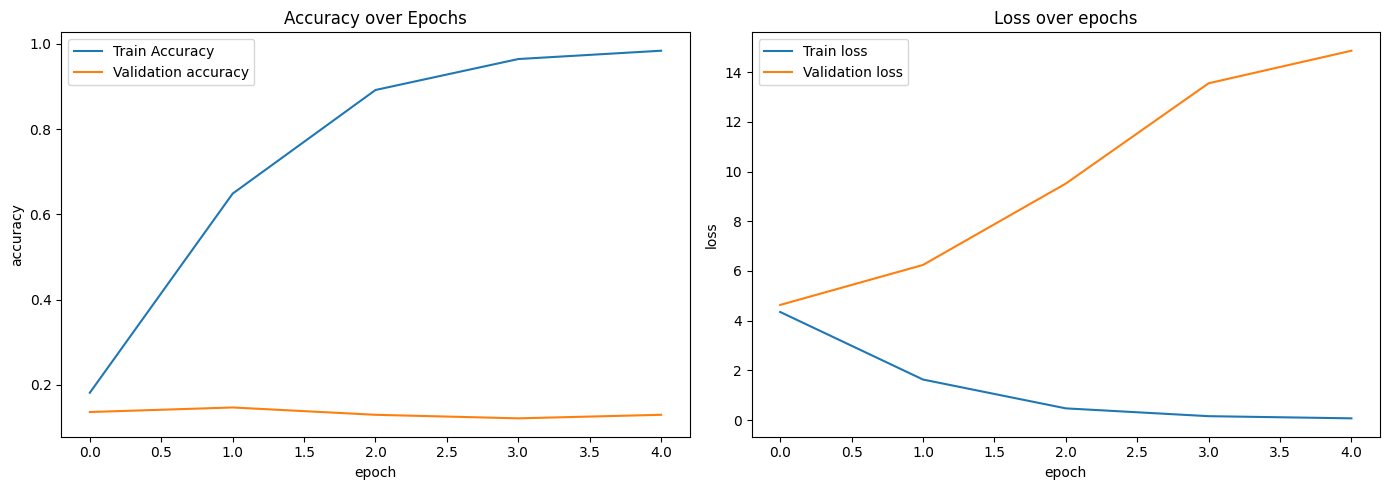

In [ ]:
plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies)


**About the baseline model, we can see that:**
* in the left plot, the train Accuracy line increases rapidly and almost reaches 1.0, indicating the model fits the training data very well and the validation Accuracy line stays very low and nearly flat, suggesting the model fails to generalize to unseen data.
* In the rigth plot, the train Loss line decreases consistently, confirming that the model is learning the training data and the validation Loss line increases steadily, showing the model performs worse on validation data over time.

**Conclusions:**
* The model is overfitting
* it's memorizing the training data but not learning generalizable patterns

In [ ]:
from sklearn.metrics import f1_score

# Load and prepare model
model.load_state_dict(torch.load('best_model_baseline.pt'))
model.to(device)
model.eval()

FamilyClassifierBaseline(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=200704, out_features=202, bias=True)
  )
)

The code bellow give the Macro F1 score:

In [ ]:
# Prepare true labels
true_labels = final_test_df['original_encoded'].tolist()

# Store predictions
y_true = []
y_pred = []

label_index = 0 # very important

with torch.no_grad():  # no gradient needed
    for images in test_loader: # only images, not (images, labels)
        images = images.to(device)
        outputs = model(images) # predictions
        _, preds = outputs.max(1)

        preds = preds.cpu().numpy()
        batch_size = preds.shape[0]

        # Extend predictions
        y_pred.extend(preds)

        # Extend corresponding true labels
        batch_true_labels = true_labels[label_index : label_index + batch_size]
        y_true.extend(batch_true_labels)

        label_index += batch_size

# Calculate Macro F1
macro_f1 = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score on Test set: {macro_f1:.4f}")

Macro F1 Score on Test set: 0.0976


As you'd expect, the Macro F1 Score of 0.0976 on the test set is very low

Next, we will evaluates Top-1 and Top-3 accuracy on the test set using a trained PyTorch model:

**Note:**
* We will output the top 1 and top 3 accuarcy. This means, since the model gets for each prediction a probability for each class, it will show the percentage of times the correct class was also the one with the highest probability given by the model (correct classification), can be seen as top 1 accuracy. It will also show the percentage of times, the correct class was in the top 3 classes with highest probabiliy given by the model, under top 3 accuracy. 
* This will be helpful to see if the model often is more lost or actually close to the correct prediction even in case of false prediction.

In [ ]:
all_paths = final_test_df['filepath'].tolist() # all image filepaths
all_top1 = []
all_top1_prob = []
all_top2 = []
all_top2_prob = []
all_top3 = []
all_top3_prob = []

#counters for the accuracies
top1_correct = 0
top3_correct = 0
total = 0

true_labels = final_test_df['original_encoded'].tolist() # make true labels to list
label_index = 0

with torch.no_grad():  # no gradient needed
    for images in test_loader:
        images = images.to(device)
        outputs = model(images) # predictions
        probs = softmax(outputs, dim=1)
        top3_probs, top3_preds = torch.topk(probs, k=3, dim=1) # top 3 predicted classes

        for j in range(images.size(0)):
            pred_top3 = top3_preds[j].cpu().tolist()
            true_label = true_labels[label_index]

            # count correct predictions (top1 and top3)
            if pred_top3[0] == true_label:
                top1_correct += 1
            if true_label in pred_top3:
                top3_correct += 1

            # save predictions and probabilites
            all_top1.append(pred_top3[0])
            all_top1_prob.append(top3_probs[j][0].item())
            all_top2.append(pred_top3[1])
            all_top2_prob.append(top3_probs[j][1].item())
            all_top3.append(pred_top3[2])
            all_top3_prob.append(top3_probs[j][2].item())

            label_index += 1
            total += 1

print(f"\nTop 1 Accuracy: {top1_correct / total:.4f}")
print(f"Top 3 Accuracy: {top3_correct / total:.4f}")



Top 1 Accuracy: 0.1291
Top 3 Accuracy: 0.2122


**Conclusions:**
* The model is correctly predicting the exact class ~13% of the time, and within the top 3 guesses ~21% of the time.
* These numbers are very low, indicating the model is struggling with generalization on the test set.

In [ ]:
#convert predictions in csv, to export them
result_df_baseline = pd.DataFrame({
    'filepath': all_paths[:len(all_top1)],
    'top1_match': all_top1,
    'top1_prob': all_top1_prob,
    'top2_match': all_top2,
    'top2_prob': all_top2_prob,
    'top3_match': all_top3,
    'top3_prob': all_top3_prob
})

result_df_baseline.to_csv("test_predictions_baseline.csv", index=False) # save as csv

In the end, we show the classes that made up the biggest parts of predictions

In [ ]:
# most predicted classes
top1_counts = Counter(result_df_baseline['top1_match'])

total_preds = len(result_df_baseline)

top1_summary = pd.DataFrame.from_dict(top1_counts, orient='index', columns=['count'])
top1_summary['percent_of_all_predictions'] = (top1_summary['count'] / total_preds * 100).round(2)
top1_summary = top1_summary.sort_values(by='count', ascending=False)

print(top1_summary.head(10))

     count  percent_of_all_predictions
34      39                        3.45
74      37                        3.27
0       26                        2.30
96      25                        2.21
68      20                        1.77
67      19                        1.68
30      19                        1.68
147     19                        1.68
187     19                        1.68
172     18                        1.59


we see that class number x was the predicted class in xx% of the time, and then a lot of classes have make up y% or lower each

<a class="anchor" id="seven-two-bullet"></a>

### <span style="color:#FF007F"> 7.2. Improved Model Based on Baseline CNN Model (FamilyClassifierTunedv1) </span>  

<a href="#top">Top &#129033;</a>

We try a upgraded version of this baseline model now, with some more advanced tunings and layers.

In [ ]:
class FamilyClassifierTunedv1(nn.Module):
    def __init__(self, num_classes):
        super(FamilyClassifierTunedv1, self).__init__()

        #three convolutional blocks
        self.conv_layers = nn.Sequential(  # we have 3 convolutional layers,
            #input channels 3 (RGB), output 32 feature maps
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            #32 input channels, output 64 feature maps
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            #input 64, output 128 feature maps
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )


        self.fc_layers = nn.Sequential(   #fully connected layer
            nn.Flatten(), # flatten data (to 1D)
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.2), # we use dropout for regularization
            nn.Linear(512, num_classes) #output layer, based on number of classes
        )

    def forward(self, x): # pass through layers
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


In [ ]:
num_classes = final_train_df['original_encoded'].nunique() # number of unique classes
model = FamilyClassifierTunedv1(num_classes) # define model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # gpu if availabe, otherwise cpu (better performance)
model.to(device)

criterion = nn.CrossEntropyLoss() # define loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005) # optimizer adam with smaller learning rate this time

In [ ]:
EPOCHS = 15 # number of epochs, 15 this time
early_stopping = EarlyStopping(patience=6, verbose=1, path='best_model_advanced.pt') # higher patience this time because of more epochs
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3) #reduce the learning rate (by factor 0.5) if validation loss does not improve for 3 epochs

#for later visualizations
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(EPOCHS):
    model.train() # train the model
    train_loss, train_correct, train_total = 0.0, 0, 0 # reset statistics

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Training", leave=False):
        images, labels = images.to(device), labels.to(device) # move batch to cpu or gpu

        outputs = model(images) # forward pass
        loss = criterion(outputs, labels) # calculate loss

        optimizer.zero_grad() #reset previous gradients
        loss.backward() # backpropagation
        optimizer.step() # update parameters of model

        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    #average loss and accurarcy
    train_loss /= train_total
    train_acc = train_correct / train_total

    model.eval() # evaluation mode
    val_loss, val_correct, val_total = 0.0, 0, 0 # reset statistics

    with torch.no_grad(): # no gradient needed
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device) # move batch to gpu/cpu
            outputs = model(images) # forward pass
            loss = criterion(outputs, labels) #calculate loss

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    #average loss and accuraccy
    val_loss /= val_total
    val_acc = val_correct / val_total

    # for plots later
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Early stopping check
    early_stopping(val_loss, model)

    # Scheduler step (neccesary to dynamically reduce learning rate or not)
    scheduler.step(val_loss)

    if early_stopping.early_stop:
        print(f"Early stopping triggered at epoch {epoch+1}") #if early stopping triggered
        break

Epoch 1/15 | Train Loss: 4.4810 | Train Acc: 0.1022 | Val Loss: 4.1758 | Val Acc: 0.1572
Validation loss decreased (inf --> 4.175764). Saving model...


Epoch 2/15 | Train Loss: 2.9293 | Train Acc: 0.3388 | Val Loss: 4.0382 | Val Acc: 0.1999
Validation loss decreased (4.175764 --> 4.038164). Saving model...


Epoch 3/15 | Train Loss: 1.8073 | Train Acc: 0.5612 | Val Loss: 4.4037 | Val Acc: 0.2278
EarlyStopping counter: 1 out of 6


Epoch 4/15 | Train Loss: 1.0802 | Train Acc: 0.7208 | Val Loss: 4.9763 | Val Acc: 0.2295
EarlyStopping counter: 2 out of 6


Epoch 5/15 | Train Loss: 0.6766 | Train Acc: 0.8149 | Val Loss: 5.8536 | Val Acc: 0.2313
EarlyStopping counter: 3 out of 6


Epoch 6/15 | Train Loss: 0.4644 | Train Acc: 0.8679 | Val Loss: 6.4552 | Val Acc: 0.2284
EarlyStopping counter: 4 out of 6


Epoch 7/15 | Train Loss: 0.2236 | Train Acc: 0.9355 | Val Loss: 7.0410 | Val Acc: 0.2402
EarlyStopping counter: 5 out of 6


Epoch 8/15 | Train Loss: 0.1639 | Train Acc: 0.9529 | Val Loss: 7.5628 | Val Acc: 0.2420
EarlyStopping counter: 6 out of 6
Early stopping triggered at epoch 8


Now again the visualizations/analysies

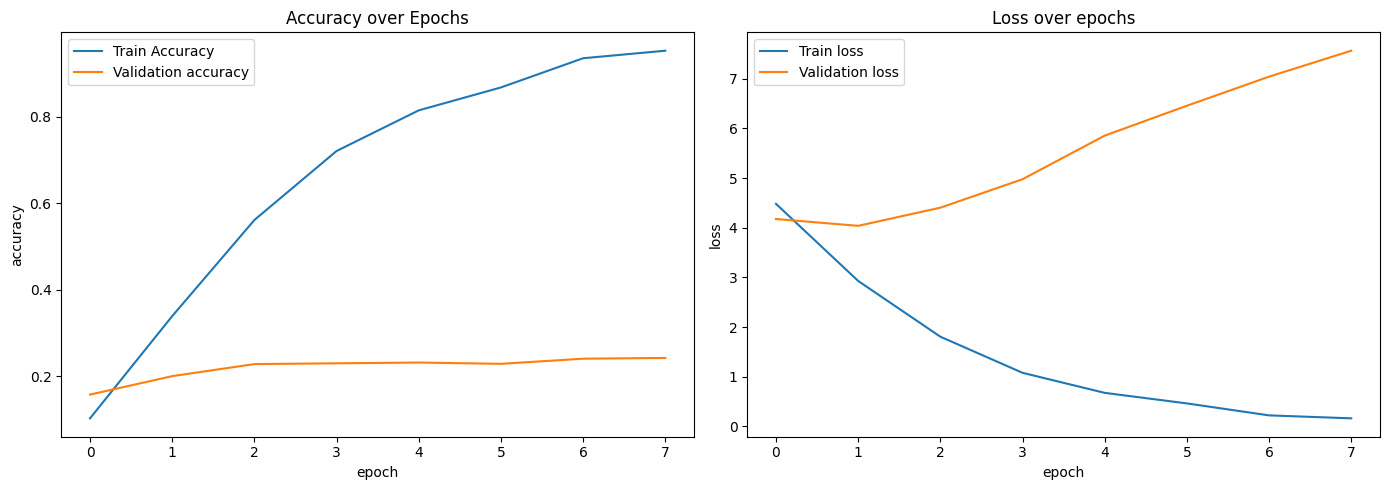

In [ ]:
plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies)

**About the baseline model (better version), we can see that:**
* in the left plot, the train Accuracy line keeps rising steadily and exceeds 90% and the validation Accuracy line increases slightly early on, but quickly plateaus around 24%
* In the rigth plot, the train Loss line drops significantly, showing the model is fitting the training data well and the validation Loss line initially decreases, but then rises steadily, indicating the model is memorizing the training data and failing to generalize

**Conclusions:**
* The model is overfitting severely: it learns training data well but doesn't improve on validation.
* A ~24% validation accuracy suggests it's doing a bit better than random, but still poor overall (especially if you have many classes).

In [ ]:
model.load_state_dict(torch.load('best_model_advanced.pt'))  # use the best model and not the last one (possible because early stopping class)
model.to(device)
model.eval()

FamilyClassifierTunedv1(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=202, bias=True)
  )
)

In [ ]:
# get macro f1 score as metric (better for unbalanced classes)
# Prepare true labels
true_labels = final_test_df['original_encoded'].tolist()

# Store predictions
y_true = []
y_pred = []

label_index = 0 # very important

with torch.no_grad():  # no gradient needed
    for images in test_loader: # only images, not (images, labels)
        images = images.to(device)
        outputs = model(images) # predictions
        _, preds = outputs.max(1)

        preds = preds.cpu().numpy()
        batch_size = preds.shape[0]

        # Extend predictions
        y_pred.extend(preds)

        # Extend corresponding true labels
        batch_true_labels = true_labels[label_index : label_index + batch_size]
        y_true.extend(batch_true_labels)

        label_index += batch_size

# Calculate Macro F1
macro_f1 = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score on Test set: {macro_f1:.4f}")

Macro F1 Score on Test set: 0.1541


This score means that is a small improvement over your previous score (0.0976), but it still indicates poor overall performance across classes.

**Note:**
* We will output the top 1 and top 3 accuarcy. This means, since the model gets for each prediction a probability for each class, it will show the percentage of times the correct class was also the one with the highest probability given by the model (correct classification), can be seen as top 1 accuracy. It will also show the percentage of times, the correct class was in the top 3 classes with highest probabiliy given by the model, under top 3 accuracy. 
* This will be helpful to see if the model often is more lost or actually close to the correct prediction even in case of false prediction.

In [ ]:
all_paths = final_test_df['filepath'].tolist() # get all image paths
all_top1 = []
all_top1_prob = []
all_top2 = []
all_top2_prob = []
all_top3 = []
all_top3_prob = []

#counters for top 3 accuracy
top1_correct = 0
top3_correct = 0
total = 0

true_labels = final_test_df['original_encoded'].tolist()
label_index = 0

with torch.no_grad():  # no gradient needed
    for images in test_loader:
        images = images.to(device)
        outputs = model(images) # predictions
        probs = softmax(outputs, dim=1)
        top3_probs, top3_preds = torch.topk(probs, k=3, dim=1) # top 3 predicted classes

        for j in range(images.size(0)):
            pred_top3 = top3_preds[j].cpu().tolist()
            true_label = true_labels[label_index]

            # count correct predictions (top1 and top3)
            if pred_top3[0] == true_label:
                top1_correct += 1
            if true_label in pred_top3:
                top3_correct += 1

            # save predictions and probabilites
            all_top1.append(pred_top3[0])
            all_top1_prob.append(top3_probs[j][0].item())
            all_top2.append(pred_top3[1])
            all_top2_prob.append(top3_probs[j][1].item())
            all_top3.append(pred_top3[2])
            all_top3_prob.append(top3_probs[j][2].item())

            label_index += 1
            total += 1

print(f"Top 1 Accuracy: {top1_correct / total:.4f}")
print(f"Top 3 Accuracy: {top3_correct / total:.4f}")


Top 1 Accuracy: 0.1919
Top 3 Accuracy: 0.3086


**Conclusions:**
* Slight improvements across all metrics suggest the model is learning somewhat better.
* Still, the Top-1 accuracy is low, meaning it predicts the correct class on the first try less than 1 in 5 times.
* Top-3 accuracy over 30% shows the model includes the correct class in its top 3 predictions more often, which can be acceptable in tasks where multiple predictions are useful (e.g., recommendation systems, visual search).

In [ ]:
#convert predictions in csv
result_df_advancedv1 = pd.DataFrame({
    'filepath': all_paths[:len(all_top1)],
    'top1_match': all_top1,
    'top1_prob': all_top1_prob,
    'top2_match': all_top2,
    'top2_prob': all_top2_prob,
    'top3_match': all_top3,
    'top3_prob': all_top3_prob
})

result_df_advancedv1.to_csv("test_predictions_advancedv1.csv", index=False) # save to csv

In the end, we show the classes that made up the biggest parts of predictions

In [ ]:
# most predicted classes
top1_counts = Counter(result_df_advancedv1['top1_match'])

total_preds = len(result_df_advancedv1)

top1_summary = pd.DataFrame.from_dict(top1_counts, orient='index', columns=['count'])
top1_summary['percent'] = (top1_summary['count'] / total_preds * 100).round(2)
top1_summary = top1_summary.sort_values(by='count', ascending=False)

print(top1_summary.head(10))

     count  percent
5       34     3.01
143     23     2.03
63      23     2.03
70      22     1.95
151     22     1.95
68      21     1.86
45      19     1.68
82      16     1.41
100     16     1.41
132     15     1.33


<a class="anchor" id="seven-tree-bullet"></a>

### <span style="color:#FF007F"> 7.3. More complex CNN Model (FamilyClassifierTunedv2) </span>  

<a href="#top">Top &#129033;</a>

Now we try a final and even more advanced model, with 4 convolutional layers, batch normalization after each of them and 2 dense layers

In [ ]:
class FamilyClassifierTunedv2(nn.Module):
    def __init__(self, num_classes):
        super(FamilyClassifierTunedv2, self).__init__()

        self.conv_layers = nn.Sequential(
            # first convolutional layer
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # 3 input channels RGB, 32 feature maps output
            nn.BatchNorm2d(32), # normalize outputs from layer
            nn.ReLU(), # activation function Relu
            nn.MaxPool2d(2), # maxpooling

            #second convolutional layer
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 32 input channels, 64 output feature maps
            nn.BatchNorm2d(64), # normalize outputs from layer
            nn.ReLU(),
            nn.MaxPool2d(2),

            #third convolutional layer
            nn.Conv2d(64, 128, kernel_size=3, padding=1), #64 input channels, 128 output feature maps
            nn.BatchNorm2d(128), # normalize outputs from layer
            nn.ReLU(),
            nn.MaxPool2d(2),

            #fourth convolutional layer
            nn.Conv2d(128, 256, kernel_size=3, padding=1), # 128 input channels, 256 output feature maps
            nn.BatchNorm2d(256), # normalize outputs from layer
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc_layers = nn.Sequential(   # two fully connected layers
            nn.Flatten(), # flatten data
            nn.Linear(256 * 14 * 14, 1024), # first dense layer
            nn.ReLU(),
            nn.Dropout(0.4),  # stronger regulization
            nn.Linear(1024, 512), # second dense layer
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes) # output layer
        )

    def forward(self, x): # for forward pass
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


In [ ]:
num_classes = final_train_df['original_encoded'].nunique() # number of unique classes
model = FamilyClassifierTunedv2(num_classes) # define model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # gpu if availabe, otherwise cpu (better performance)
model.to(device)

criterion = nn.CrossEntropyLoss() # define loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005) # optimizer adam and learning rate

In [ ]:
EPOCHS = 30 # number of epochs, 30 this time
early_stopping = EarlyStopping(patience=6, verbose=1, path='best_model_advancedv2.pt') # higher patience this time because of more epochs
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3) #reduce the learning rate (by factor 0.5) if validation loss does not improve for 3 epochs

#for later visualizations
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(EPOCHS):
    model.train() # train the model
    train_loss, train_correct, train_total = 0.0, 0, 0 # reset statistics

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Training", leave=False):
        images, labels = images.to(device), labels.to(device) # move batch to cpu or gpu

        outputs = model(images) # forward pass
        loss = criterion(outputs, labels) # calculate loss

        optimizer.zero_grad() #reset previous gradients
        loss.backward() # backpropagation
        optimizer.step() # update parameters of model

        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    #average loss and accurarcy
    train_loss /= train_total
    train_acc = train_correct / train_total

    model.eval() # evaluation mode
    val_loss, val_correct, val_total = 0.0, 0, 0 # reset statistics

    with torch.no_grad(): # no gradient needed
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device) # move batch to gpu/cpu
            outputs = model(images) # forward pass
            loss = criterion(outputs, labels) #calculate loss

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    #average loss and accuraccy
    val_loss /= val_total
    val_acc = val_correct / val_total

    # for plots later
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Early stopping check
    early_stopping(val_loss, model)

    # Scheduler step (neccesary to dynamically reduce learning rate or not)
    scheduler.step(val_loss)

    if early_stopping.early_stop:
        print(f"Early stopping triggered at epoch {epoch+1}") #if early stopping triggered
        break

Epoch 1/30 | Train Loss: 5.0306 | Train Acc: 0.0323 | Val Loss: 4.7065 | Val Acc: 0.0575
Validation loss decreased (inf --> 4.706519). Saving model...


Epoch 2/30 | Train Loss: 4.5018 | Train Acc: 0.0748 | Val Loss: 4.3452 | Val Acc: 0.0902
Validation loss decreased (4.706519 --> 4.345195). Saving model...


Epoch 3/30 | Train Loss: 4.1508 | Train Acc: 0.1121 | Val Loss: 4.1924 | Val Acc: 0.1192
Validation loss decreased (4.345195 --> 4.192367). Saving model...


Epoch 4/30 | Train Loss: 3.8592 | Train Acc: 0.1487 | Val Loss: 3.9739 | Val Acc: 0.1465
Validation loss decreased (4.192367 --> 3.973860). Saving model...


Epoch 5/30 | Train Loss: 3.6140 | Train Acc: 0.1840 | Val Loss: 3.9541 | Val Acc: 0.1679
Validation loss decreased (3.973860 --> 3.954138). Saving model...


...

Epoch 19/30 | Train Loss: 1.8167 | Train Acc: 0.5178 | Val Loss: 3.5033 | Val Acc: 0.2616
EarlyStopping counter: 2 out of 6


Epoch 20/30 | Train Loss: 1.7521 | Train Acc: 0.5325 | Val Loss: 3.5092 | Val Acc: 0.2628
EarlyStopping counter: 3 out of 6


Epoch 21/30 | Train Loss: 1.6621 | Train Acc: 0.5534 | Val Loss: 3.4726 | Val Acc: 0.2752
EarlyStopping counter: 4 out of 6


Epoch 22/30 | Train Loss: 1.4570 | Train Acc: 0.6012 | Val Loss: 3.4631 | Val Acc: 0.2776
EarlyStopping counter: 5 out of 6


Epoch 23/30 | Train Loss: 1.3652 | Train Acc: 0.6225 | Val Loss: 3.5367 | Val Acc: 0.2865
EarlyStopping counter: 6 out of 6
Early stopping triggered at epoch 23


Now again the visualizations/analysies

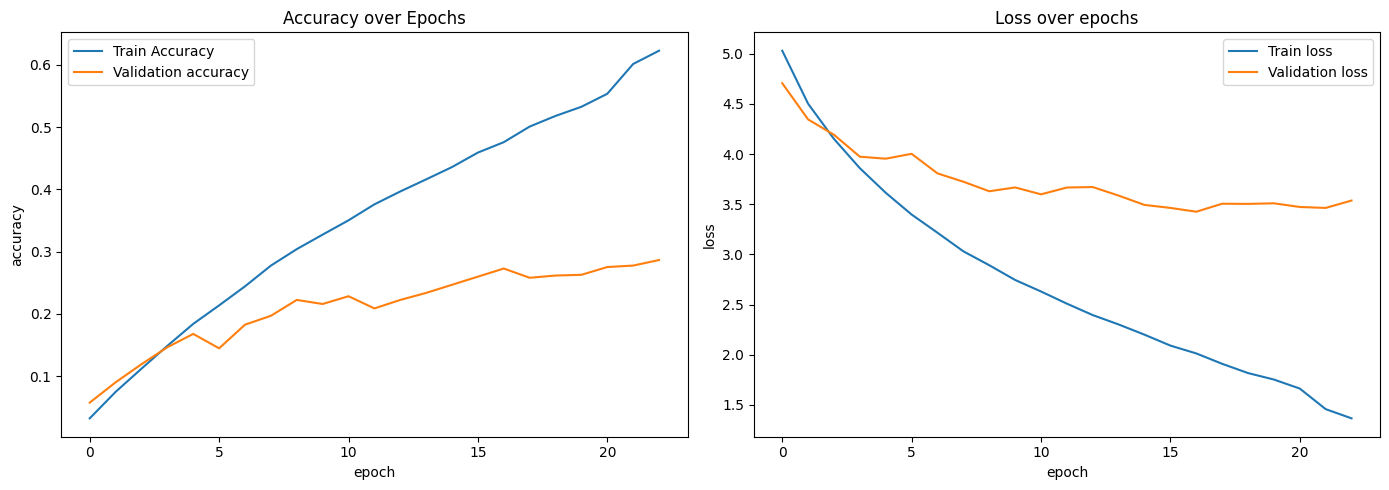

In [ ]:
plot_training_curves(train_losses, val_losses, train_accuracies, val_accuracies)

**About the complex CNN model, we can see that:**
* in the left plot, the train Accuracy line rises steadily and reaches over 60% and the validation Accuracy line also improves more than before, climbing to nearly 30%, although it plateaus and shows some instability
* In the rigth plot, the train Loss line decreases consistently — the model is learning and the validation Loss line  drops initially and then flattens, with some fluctuations

**Conclusions:**
* Compared to your earlier graphs, validation accuracy and loss have both improved.
* Model overfitting is less severe

In [ ]:
# get macro f1 score as metric (better for unbalanced classes)
model.load_state_dict(torch.load('best_model_advancedv2.pt'))  # use the best model and not the last one (possible because early stopping class)
model.to(device)
model.eval()

FamilyClassifierTunedv2(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_ru

In [ ]:
# Prepare true labels
true_labels = final_test_df['original_encoded'].tolist()

# Store predictions
y_true = []
y_pred = []

label_index = 0 # very important

with torch.no_grad():  # no gradient needed
    for images in test_loader: # only images, not (images, labels)
        images = images.to(device)
        outputs = model(images) # predictions
        _, preds = outputs.max(1)

        preds = preds.cpu().numpy()
        batch_size = preds.shape[0]

        # Extend predictions
        y_pred.extend(preds)

        # Extend corresponding true labels
        batch_true_labels = true_labels[label_index : label_index + batch_size]
        y_true.extend(batch_true_labels)

        label_index += batch_size

# Calculate Macro F1
macro_f1 = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score on Test set: {macro_f1:.4f}")

Macro F1 Score on Test set: 0.2129


This Score of 0.2129 indicates continued gradual improvement

**Note:**
* We will output the top 1 and top 3 accuarcy. This means, since the model gets for each prediction a probability for each class, it will show the percentage of times the correct class was also the one with the highest probability given by the model (correct classification), can be seen as top 1 accuracy. It will also show the percentage of times, the correct class was in the top 3 classes with highest probabiliy given by the model, under top 3 accuracy. 
* This will be helpful to see if the model often is more lost or actually close to the correct prediction even in case of false prediction.

In [ ]:
model.load_state_dict(torch.load('best_model_advancedv2.pt'))  # use best model, not last one (because early stopping class possible)
model.to(device)
model.eval()


all_paths = final_test_df['filepath'].tolist() # get all image paths
all_top1 = []
all_top1_prob = []
all_top2 = []
all_top2_prob = []
all_top3 = []
all_top3_prob = []

#counters for top 3 accuracy
top1_correct = 0
top3_correct = 0
total = 0

true_labels = final_test_df['original_encoded'].tolist()
label_index = 0

with torch.no_grad():  # no gradient needed
    for images in test_loader:
        images = images.to(device)
        outputs = model(images) # predictions
        probs = softmax(outputs, dim=1)
        top3_probs, top3_preds = torch.topk(probs, k=3, dim=1) # top 3 predicted classes

        for j in range(images.size(0)):
            pred_top3 = top3_preds[j].cpu().tolist()
            true_label = true_labels[label_index]

            # count correct predictions (top1 and top3)
            if pred_top3[0] == true_label:
                top1_correct += 1
            if true_label in pred_top3:
                top3_correct += 1

            # save predictions and probabilites
            all_top1.append(pred_top3[0])
            all_top1_prob.append(top3_probs[j][0].item())
            all_top2.append(pred_top3[1])
            all_top2_prob.append(top3_probs[j][1].item())
            all_top3.append(pred_top3[2])
            all_top3_prob.append(top3_probs[j][2].item())

            label_index += 1
            total += 1

print(f"Top 1 Accuracy: {top1_correct / total:.4f}")
print(f"Top 3 Accuracy: {top3_correct / total:.4f}")


Top 1 Accuracy: 0.2485
Top 3 Accuracy: 0.4103


**Conclusions:**
* Top-1 Accuracy nearing 25%: much better than chance (especially if many classes), showing the model is learning meaningful patterns.
* Top-3 Accuracy over 40%: promising — the correct class is among the top 3 predictions in 4 out of 10 cases.

In [ ]:
#convert predictions in csv
result_df_advancedv2 = pd.DataFrame({
    'filepath': all_paths[:len(all_top1)],
    'top1_match': all_top1,
    'top1_prob': all_top1_prob,
    'top2_match': all_top2,
    'top2_prob': all_top2_prob,
    'top3_match': all_top3,
    'top3_prob': all_top3_prob
})

result_df_advancedv2.to_csv("test_predictions_advancedv2.csv", index=False) # save to csv

In [ ]:
# most predicted classes
top1_counts = Counter(result_df_advancedv2['top1_match'])

total_preds = len(result_df_advancedv2)

top1_summary = pd.DataFrame.from_dict(top1_counts, orient='index', columns=['count'])
top1_summary['percent'] = (top1_summary['count'] / total_preds * 100).round(2)
top1_summary = top1_summary.sort_values(by='count', ascending=False)

print(top1_summary.head(10))

     count  percent
5       24     2.12
30      21     1.86
68      21     1.86
38      17     1.50
70      16     1.41
74      15     1.33
140     15     1.33
0       14     1.24
103     14     1.24
186     14     1.24


<a class="anchor" id="seven-four-bullet"></a>

### <span style="color:#FF007F"> 7.4. Pretrained Model ResNet50 (FamilyClassifierResNet50) </span>  

<a href="#top">Top &#129033;</a>

In [32]:
num_classes = final_train_df['original_encoded'].nunique()

In [33]:
# RESNET50 Model
resnet50_model = models.resnet50(pretrained=True)
num_ftrs = resnet50_model.fc.in_features
resnet50_model.fc = nn.Linear(num_ftrs, num_classes)
resnet50_model = resnet50_model.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 156MB/s]


In [34]:
# ResNet50 Training Setup
criterion = nn.CrossEntropyLoss()
optimizer_resnet = torch.optim.Adam(resnet50_model.parameters(), lr=0.0005)
scheduler_resnet = ReduceLROnPlateau(optimizer_resnet, mode='min', factor=0.5, patience=5)
early_stopping_resnet = EarlyStopping(patience=6, verbose=True, path='best_model_resnet50.pt')

EPOCHS = 15

train_losses_resnet = []
val_losses_resnet = []
train_accuracies_resnet = []
val_accuracies_resnet = []

for epoch in range(EPOCHS):
    resnet50_model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    loop = tqdm(train_loader, desc=f'ResNet50 - Epoch [{epoch+1}/{EPOCHS}]', leave=False)

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        outputs = resnet50_model(images)
        loss = criterion(outputs, labels)

        optimizer_resnet.zero_grad()
        loss.backward()
        optimizer_resnet.step()

        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

        loop.set_postfix(loss=loss.item())

    train_loss /= train_total
    train_acc = train_correct / train_total

    resnet50_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = resnet50_model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss /= val_total
    val_acc = val_correct / val_total

    train_losses_resnet.append(train_loss)
    val_losses_resnet.append(val_loss)
    train_accuracies_resnet.append(train_acc)
    val_accuracies_resnet.append(val_acc)

    print(f"ResNet50 - Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    early_stopping_resnet(val_loss, resnet50_model)
    scheduler_resnet.step(val_loss)

    if early_stopping_resnet.early_stop:
        print(f"Early stopping triggered for ResNet50 at epoch {epoch+1}")
        break

ResNet50 - Epoch 1/15 | Train Loss: 2.0004 | Train Acc: 0.5133 | Val Loss: 2.3417 | Val Acc: 0.4502
Validation loss decreased (inf --> 2.341716). Saving model...


ResNet50 - Epoch 2/15 | Train Loss: 0.6713 | Train Acc: 0.8090 | Val Loss: 2.2582 | Val Acc: 0.5065
Validation loss decreased (2.341716 --> 2.258158). Saving model...


ResNet50 - Epoch 3/15 | Train Loss: 0.3670 | Train Acc: 0.8927 | Val Loss: 2.5626 | Val Acc: 0.4929
EarlyStopping counter: 1 out of 6


ResNet50 - Epoch 4/15 | Train Loss: 0.2561 | Train Acc: 0.9249 | Val Loss: 2.5408 | Val Acc: 0.5012
EarlyStopping counter: 2 out of 6


ResNet50 - Epoch 5/15 | Train Loss: 0.2042 | Train Acc: 0.9384 | Val Loss: 2.2860 | Val Acc: 0.5658
EarlyStopping counter: 3 out of 6


ResNet50 - Epoch 6/15 | Train Loss: 0.1695 | Train Acc: 0.9486 | Val Loss: 2.9642 | Val Acc: 0.4769
EarlyStopping counter: 4 out of 6


ResNet50 - Epoch 7/15 | Train Loss: 0.1657 | Train Acc: 0.9491 | Val Loss: 2.5647 | Val Acc: 0.5421
EarlyStopping counter: 5 out of 6


ResNet50 - Epoch 8/15 | Train Loss: 0.1235 | Train Acc: 0.9624 | Val Loss: 2.9435 | Val Acc: 0.5302
EarlyStopping counter: 6 out of 6
Early stopping triggered for ResNet50 at epoch 8


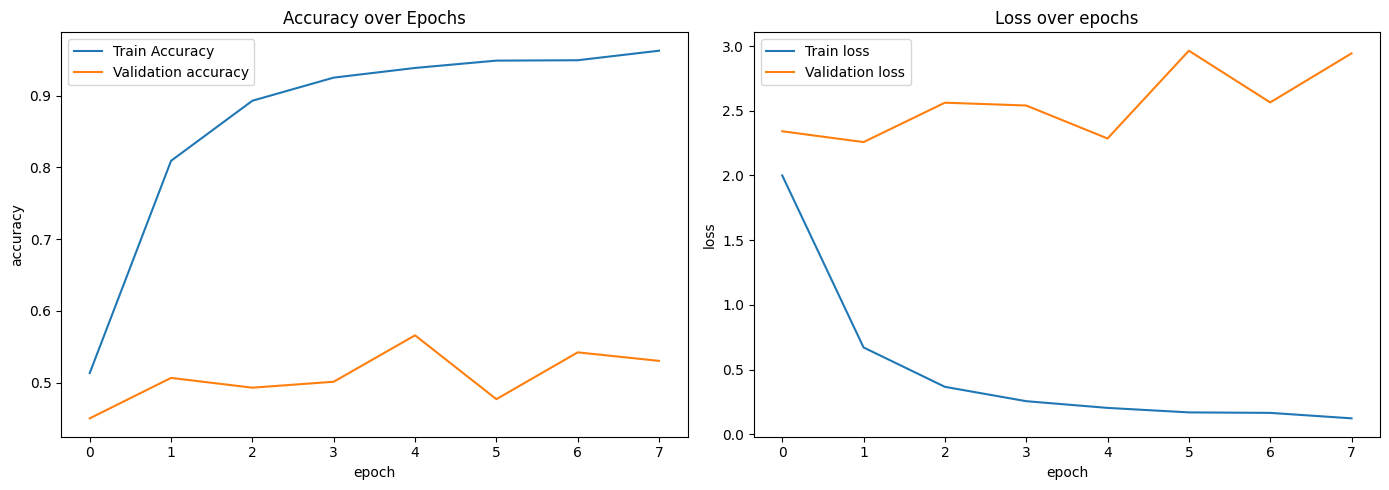

In [35]:
plot_training_curves(train_losses_resnet, val_losses_resnet, train_accuracies_resnet, val_accuracies_resnet)

**About the ResNet50, we can see that:**
* in the left plot, the train Accuracy line climbs quickly and reaches around 96% and the validation Accuracy increases slowly up to around 50%, indicating the model is memorizing the training data but still struggling to generalize with same power.
* In the rigth plot, the train Loss line decreases smoothly and steadily and validation Accuracy line fluctuates and trends upward, suggesting increasing overfitting as training progresses

**Conclusions:**
* Despite the model performing still showing clear signs of overfitting, the accuracy and loss show way better and more solid results than in previous models, whith solid values for our classification problem of more than 200 classes.

In [36]:
# Evaluate ResNet50
print("\nEvaluating ResNet50 on Test Set")
resnet50_model.load_state_dict(torch.load('best_model_resnet50.pt'))
resnet50_model.eval()


Evaluating ResNet50 on Test Set


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [37]:
# Prepare true labels
true_labels = final_test_df['original_encoded'].tolist()

# Store predictions
y_true = []
y_pred = []

label_index = 0 # very important

with torch.no_grad():  # no gradient needed
    for images in test_loader: # only images, not (images, labels)
        images = images.to(device)
        outputs = resnet50_model(images) # predictions
        _, preds = outputs.max(1)

        preds = preds.cpu().numpy()
        batch_size = preds.shape[0]

        # Extend predictions
        y_pred.extend(preds)

        # Extend corresponding true labels
        batch_true_labels = true_labels[label_index : label_index + batch_size]
        y_true.extend(batch_true_labels)

        label_index += batch_size

# Calculate Macro F1
macro_f1 = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score on Test set: {macro_f1:.4f}")

Macro F1 Score on Test set: 0.4578


A Macro F1 Score of 0.4578 is a significant improvement — nearly double your previous best.

In [38]:
all_paths = final_test_df['filepath'].tolist()
all_top1 = []
all_top1_prob = []
all_top2 = []
all_top2_prob = []
all_top3 = []
all_top3_prob = []

top1_correct = 0
top3_correct = 0
total = 0

true_labels = final_test_df['original_encoded'].tolist()
label_index = 0

with torch.no_grad():
    for images in test_loader:
        images = images.to(device)
        outputs = resnet50_model(images)
        probs = softmax(outputs, dim=1)
        top3_probs, top3_preds = torch.topk(probs, k=3, dim=1)

        for j in range(images.size(0)):
            pred_top3 = top3_preds[j].cpu().tolist()
            true_label = true_labels[label_index]

            if pred_top3[0] == true_label:
                top1_correct += 1
            if true_label in pred_top3:
                top3_correct += 1

            all_top1.append(pred_top3[0])
            all_top1_prob.append(top3_probs[j][0].item())
            all_top2.append(pred_top3[1])
            all_top2_prob.append(top3_probs[j][1].item())
            all_top3.append(pred_top3[2])
            all_top3_prob.append(top3_probs[j][2].item())

            label_index += 1
            total += 1

print(f"\nTop-1 Accuracy (ResNet50): {top1_correct / total:.4f}")
print(f"Top-3 Accuracy (ResNet50): {top3_correct / total:.4f}")


Top-1 Accuracy (ResNet50): 0.4898
Top-3 Accuracy (ResNet50): 0.6888


**Conclusions:**
* This model correctly classifies nearly 1 in 2 samples on the first guess, and nearly 7 in 10 within the top 3 guesses — very solid for a multi-class task.

In [41]:
# ResNet50 Most Predicted Classes Summary
top1_counts = Counter(result_df_resnet['top1_match'])
total_preds = len(result_df_resnet)

top1_summary = pd.DataFrame.from_dict(top1_counts, orient='index', columns=['count'])
top1_summary['percent'] = (top1_summary['count'] / total_preds * 100).round(2)
top1_summary = top1_summary.sort_values(by='count', ascending=False)


In [42]:
# Save ResNet Test Predictions to CSV
result_df_resnet = pd.DataFrame({
    'filepath': all_paths[:len(all_top1)],
    'top1_match': all_top1,
    'top1_prob': all_top1_prob,
    'top2_match': all_top2,
    'top2_prob': all_top2_prob,
    'top3_match': all_top3,
    'top3_prob': all_top3_prob
})

result_df_resnet.to_csv("test_predictions_resnet.csv", index=False)


print(top1_summary.head(10))

     count  percent
132     43     3.80
5       31     2.74
30      27     2.39
187     26     2.30
68      25     2.21
76      25     2.21
38      23     2.03
96      21     1.86
183     18     1.59
48      17     1.50


<a class="anchor" id="seven-ffive-bullet"></a>

### <span style="color:#FF007F"> 7.5. Pretrained Model VGG16 (FamilyClassifierVGG16) </span>  

<a href="#top">Top &#129033;</a>

In [43]:
# VGG16 Model
vgg16_model = models.vgg16(pretrained=True)
num_ftrs = vgg16_model.classifier[6].in_features
vgg16_model.classifier[6] = nn.Linear(num_ftrs, num_classes)
vgg16_model = vgg16_model.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:04<00:00, 134MB/s]


VGG16 - Epoch 1/15 | Train Loss: 5.1076 | Train Acc: 0.0204 | Val Loss: 4.7574 | Val Acc: 0.0534
Validation loss decreased (inf --> 4.757410). Saving model...


VGG16 - Epoch 2/15 | Train Loss: 4.3216 | Train Acc: 0.1023 | Val Loss: 4.3360 | Val Acc: 0.1204
Validation loss decreased (4.757410 --> 4.335996). Saving model...


VGG16 - Epoch 3/15 | Train Loss: 3.4411 | Train Acc: 0.2348 | Val Loss: 4.1145 | Val Acc: 0.1578
Validation loss decreased (4.335996 --> 4.114530). Saving model...


VGG16 - Epoch 4/15 | Train Loss: 2.5161 | Train Acc: 0.4079 | Val Loss: 4.1474 | Val Acc: 0.1880
EarlyStopping counter: 1 out of 6


VGG16 - Epoch 5/15 | Train Loss: 1.7635 | Train Acc: 0.5680 | Val Loss: 4.3198 | Val Acc: 0.1951
EarlyStopping counter: 2 out of 6


VGG16 - Epoch 6/15 | Train Loss: 1.2587 | Train Acc: 0.6778 | Val Loss: 4.5371 | Val Acc: 0.2052
EarlyStopping counter: 3 out of 6


VGG16 - Epoch 7/15 | Train Loss: 0.9120 | Train Acc: 0.7587 | Val Loss: 4.9092 | Val Acc: 0.2159
EarlyStopping counter: 4 out of 6


VGG16 - Epoch 8/15 | Train Loss: 0.7054 | Train Acc: 0.8070 | Val Loss: 5.2612 | Val Acc: 0.2218
EarlyStopping counter: 5 out of 6


VGG16 - Epoch 9/15 | Train Loss: 0.5570 | Train Acc: 0.8460 | Val Loss: 5.3850 | Val Acc: 0.2183
EarlyStopping counter: 6 out of 6
Early stopping triggered for VGG16 at epoch 9


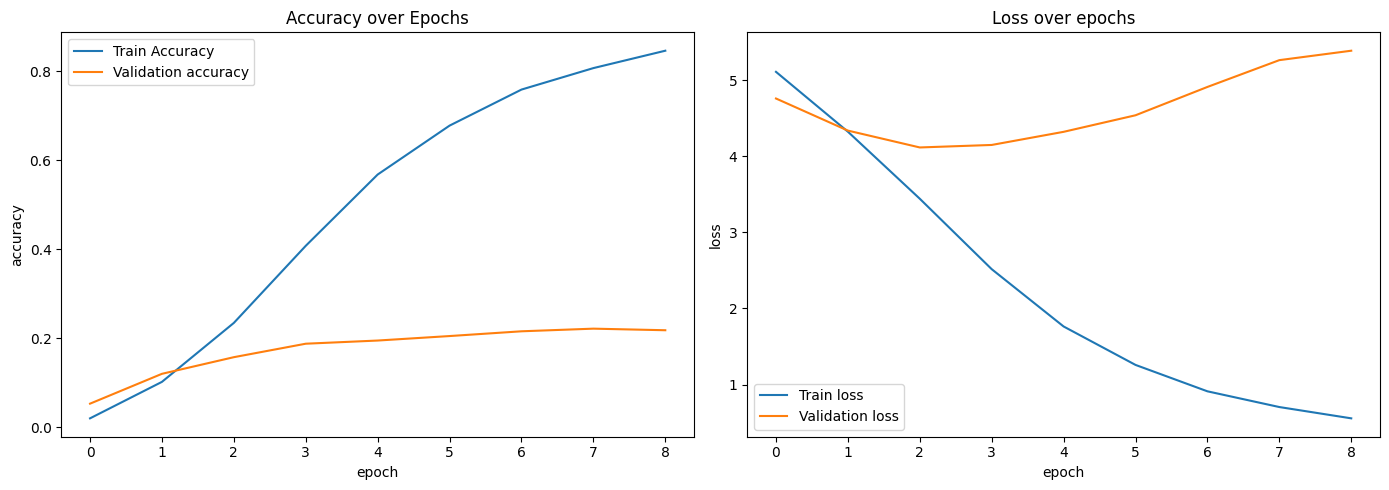

In [44]:
# VGG16 Training Setup
criterion_vgg = nn.CrossEntropyLoss()
optimizer_vgg = torch.optim.Adam(vgg16_model.parameters(), lr=0.0005)
scheduler_vgg = ReduceLROnPlateau(optimizer_vgg, mode='min', factor=0.5, patience=5)
early_stopping_vgg = EarlyStopping(patience=6, verbose=True, path='best_model_vgg16.pt')

EPOCHS = 15

train_losses_vgg = []
val_losses_vgg = []
train_accuracies_vgg = []
val_accuracies_vgg = []

for epoch in range(EPOCHS):
    vgg16_model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    loop = tqdm(train_loader, desc=f'VGG16 - Epoch [{epoch+1}/{EPOCHS}]', leave=False)

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        outputs = vgg16_model(images)
        loss = criterion_vgg(outputs, labels)

        optimizer_vgg.zero_grad()
        loss.backward()
        optimizer_vgg.step()

        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

        loop.set_postfix(loss=loss.item())

    train_loss /= train_total
    train_acc = train_correct / train_total

    vgg16_model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = vgg16_model(images)
            loss = criterion_vgg(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss /= val_total
    val_acc = val_correct / val_total

    train_losses_vgg.append(train_loss)
    val_losses_vgg.append(val_loss)
    train_accuracies_vgg.append(train_acc)
    val_accuracies_vgg.append(val_acc)

    print(f"VGG16 - Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    early_stopping_vgg(val_loss, vgg16_model)
    scheduler_vgg.step(val_loss)

    if early_stopping_vgg.early_stop:
        print(f"Early stopping triggered for VGG16 at epoch {epoch+1}")
        break

# VGG16 Training Curve Plot
plot_training_curves(train_losses_vgg, val_losses_vgg, train_accuracies_vgg, val_accuracies_vgg)



**About the VGG-16, we can see that:**
* in the left plot, the train Accuracy line rises sharply, reaching ~85% by epoch 8 and the validation Accuracy line improves early but plateaus around 20%, showing limited generalization
* In the rigth plot, the train Loss line drops steadily and the validation Accuracy line decreases slightly at first, but then increases continuously, indicating overfitting from around epoch 3–4 onward.

**Conclusions:**
* VGG16, while powerful, tends to overfit quickly on small or imbalanced datasets unless heavily regularized.

In [45]:
# Evaluate VGG16 on Test Set
print("\nEvaluating VGG16 on Test Set")
vgg16_model.load_state_dict(torch.load('best_model_vgg16.pt'))
vgg16_model.eval()


Evaluating VGG16 on Test Set


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [47]:
# Prepare true labels
true_labels = final_test_df['original_encoded'].tolist()

# Store predictions
y_true = []
y_pred = []

label_index = 0 # very important

with torch.no_grad():  # no gradient needed
    for images in test_loader: # only images, not (images, labels)
        images = images.to(device)
        outputs = vgg16_model(images) # predictions
        _, preds = outputs.max(1)

        preds = preds.cpu().numpy()
        batch_size = preds.shape[0]

        # Extend predictions
        y_pred.extend(preds)

        # Extend corresponding true labels
        batch_true_labels = true_labels[label_index : label_index + batch_size]
        y_true.extend(batch_true_labels)

        label_index += batch_size

# Calculate Macro F1
macro_f1 = f1_score(y_true, y_pred, average='macro')
print(f"Macro F1 Score on Test set: {macro_f1:.4f}")

Macro F1 Score on Test set: 0.1153


**Conclusions:**
* very poor generalization and strong overfitting

In [48]:
all_paths = final_test_df['filepath'].tolist()
all_top1 = []
all_top1_prob = []
all_top2 = []
all_top2_prob = []
all_top3 = []
all_top3_prob = []

top1_correct = 0
top3_correct = 0
total = 0

true_labels = final_test_df['original_encoded'].tolist()
label_index = 0

with torch.no_grad():
    for images in test_loader:
        images = images.to(device)
        outputs = vgg16_model(images)
        probs = softmax(outputs, dim=1)
        top3_probs, top3_preds = torch.topk(probs, k=3, dim=1)

        for j in range(images.size(0)):
            pred_top3 = top3_preds[j].cpu().tolist()
            true_label = true_labels[label_index]

            if pred_top3[0] == true_label:
                top1_correct += 1
            if true_label in pred_top3:
                top3_correct += 1

            all_top1.append(pred_top3[0])
            all_top1_prob.append(top3_probs[j][0].item())
            all_top2.append(pred_top3[1])
            all_top2_prob.append(top3_probs[j][1].item())
            all_top3.append(pred_top3[2])
            all_top3_prob.append(top3_probs[j][2].item())

            label_index += 1
            total += 1

print(f"\nTop-1 Accuracy (VGG16): {top1_correct / total:.4f}")
print(f"Top-3 Accuracy (VGG16): {top3_correct / total:.4f}")


Top-1 Accuracy (VGG16): 0.1565
Top-3 Accuracy (VGG16): 0.2538


**Conclusions:**
* The model is struggling significantly — it gets the correct class on the first try only 1 in 6 times, and within the top 3 only 1 in 4 times.
* These poor results align with the training curve, which showed high overfitting and stagnant validation accuracy.

In [50]:
# Save VGG16 Test Predictions to CSV
result_df_vgg = pd.DataFrame({
    'filepath': all_paths[:len(all_top1)],
    'top1_match': all_top1,
    'top1_prob': all_top1_prob,
    'top2_match': all_top2,
    'top2_prob': all_top2_prob,
    'top3_match': all_top3,
    'top3_prob': all_top3_prob
})

result_df_vgg.to_csv("test_predictions_vgg16.csv", index=False)


print(top1_summary.head(10))

     count  percent
132     43     3.80
5       31     2.74
30      27     2.39
187     26     2.30
68      25     2.21
76      25     2.21
38      23     2.03
96      21     1.86
183     18     1.59
48      17     1.50


In [51]:
;# VGG16 Most Predicted Classes Summary
top1_counts = Counter(result_df_vgg['top1_match'])
total_preds = len(result_df_vgg)

top1_summary = pd.DataFrame.from_dict(top1_counts, orient='index', columns=['count'])
top1_summary['percent'] = (top1_summary['count'] / total_preds * 100).round(2)
top1_summary = top1_summary.sort_values(by='count', ascending=False)
